# 完全保存用の独立した再実行

このNotebookは notebooks/10_svd/20_fashion_mnist_mlp/03_mlp_svd_finetuning_using_src_corrected.ipynb の新規run。過去runの復元ではなく、baseline重み・全rankの未丸め値・FT各epoch履歴・測定条件を新しい出力先へ保存する。元の説明・条件・TODOを保持し、変更は出力先・進捗ログ・保存用セルだけ。

元Notebook中の「未実行」「過去の欠落」は複製元runへの説明。以下の新規runの実行状態は末尾のrun_manifest.jsonと各セルのexecution_countで確認する。

実行後の命名整理：Notebook名とEXPERIMENT_NAMEを `_rerun` に揃え、results/modelsの対応ディレクトリも改名した。学習・評価は再実行していない。セルの出力ログにある日時付き旧パスは実行当時の記録であり、現在の保存先はEXPERIMENT_NAMEとrun_manifest.jsonの各pathを参照する。数値・図・execution_countは改名前の実行結果を保持する。


In [1]:
# 独立した新規run。元Notebook/CSV/重みを上書きしない。
import sys
from pathlib import Path
_run_root = Path.cwd().resolve()
while not (_run_root / "src" / "nn_compression").is_dir() and _run_root.parent != _run_root:
    _run_root = _run_root.parent
sys.path.insert(0, str(_run_root / "src"))
RUN_BATCH_ID = 'rerun_20260912T074153Z'
RUN_SOURCE_RELATIVE = 'notebooks/10_svd/20_fashion_mnist_mlp/03_mlp_svd_finetuning_using_src_corrected.ipynb'
RUN_NOTEBOOK_RELATIVE = 'notebooks/10_svd/20_fashion_mnist_mlp/03_mlp_svd_finetuning_using_src_corrected_rerun.ipynb'
RUN_SOURCE_SNAPSHOT_SHA256 = '083d872bf2cb7423cb5625ddc82a163f27c651ac371f9fd942818f32991c9994'
print("独立新規run:", RUN_BATCH_ID, RUN_SOURCE_RELATIVE)


独立新規run: rerun_20260912T074153Z notebooks/10_svd/20_fashion_mnist_mlp/03_mlp_svd_finetuning_using_src_corrected.ipynb


# Fashion-MNIST MLP + SVD Fine-tuning（`src` / corrected）

このNotebookは、既存の `03_mlp_svd_finetuning.ipynb` と同じ実験を題材に、**`.py` と `.ipynb` の役割分担**を学ぶための教材です。

- `.py`：別の実験でも繰り返し使う処理を書く場所
- `.ipynb`：今回の実験条件、途中結果、グラフ、考察を書く場所

既存Notebookは参照実装として変更せず、このNotebookでは `nn_compression` パッケージをimportして利用します。

> 実験ロジックは元の03を維持します。元の結果を上書きしないため、出力先は `03_mlp_svd_finetuning_using_src_corrected`。 候補比較では rank ごとに seed を変えない。 原本・using_src は実験履歴として残す。

## corrected版で変更した点

この Notebook は **SVD の数式を変えたものではない**。
原本 `03_mlp_svd_finetuning.ipynb` / `03_mlp_svd_finetuning_using_src.ipynb` からの差分は、実験評価・再現性・現行 src の API 契約の修正である。

- **val/test 分離**: 分割（train 50k / val 5k / rank-val 5k / test 10k）と「test は最終選択後だけ」は原本から維持。
- **candidate 間の seed 公平化**: 原本・using_src は Fine-tuning で `SEED + 1000 * fc1_rank + fc2_rank` と候補ごとに seed をずらしていた。corrected は全候補を `SEED = 0` に戻す（Dropout / shuffle が rank と交絡しないようにする）。
- **DataLoader Generator 管理**: 各候補の Fine-tuning 前に `train_generator.manual_seed(SEED)` で shuffle 順を揃える。
- **train_eval_loader**: using_src は未指定。corrected は `shuffle=False` の loader を baseline / Fine-tuning の `fit_with_early_stopping` に渡す。
- **同一 input batch の benchmark**: rank 選択用 validation から取った同じ `input_batch` を baseline / compressed で共有する。
- **warmup / repeats の統一**: 原本は compressed 側が 5/200。corrected は両方 `20` / `2000`。
- **model 非共有**: rank sweep で全候補 model を表に残さない。Fine-tuning は `deepcopy(pareto_row["model"])` ではなく、baseline から `fc1_rank` / `fc2_rank` で再構築する。
- **include_model=False への対応**: 結果表に model 列が無いので、表示は `drop(columns=["model"], errors="ignore")`。Fine-tuning 済みの `fine_tuned_records["model"]` は選択・保存用なので残す。
- **corrected 専用保存先**: `03_mlp_svd_finetuning_using_src_corrected`。

## 2026-09-12 保存成果物監査への対応

保存出力から復元したCSVは `*_saved_output.csv` / `rank_sweep_saved_log.csv` として区別する。表示値は丸め済みであり、未表示列・FTのepoch別履歴・同一runのbaseline重みは復元していない。今回追記したbaseline/全rank/履歴保存処理は、次の実行で有効になる。過去runの数値へ新規実行値を混ぜない。

保存出力の整合性と、現行コードのRun All成功は別の確認である。未実行の追加処理があるセルはexecution_countを空にし、既存outputは過去記録として保持した。


## 1. import：Notebookから `.py` の処理を呼び出す

`pip install -e .` 済みなので、プロジェクト内の実装を通常のPythonパッケージとしてimportできます。

**元の03との一番大きな違い:**  
元の03では `def set_seed(...)` や `class MNISTMLP(...)` をNotebook内に何度も書いていました。  
この教材版では、同じ処理を `src/nn_compression/` の `.py` に置き、ここから呼び出します。

主な対応は次のとおりです。

| import | 実体のファイル | 元03での扱い |
|---|---|---|
| `MNISTMLP` | `models/mlp.py` | Notebook内で `class MNISTMLP` を定義 |
| `make_two_layer_svd_model`, `retained_energy` | `compression/svd.py` | Notebook内で `def` 定義 |
| `evaluate`, `fit_with_early_stopping` | `training/loops.py`, `training/fit.py` | `train_one_epoch` / `evaluate` / Early Stoppingループをセル内に記述 |
| `count_parameters`, `agreement` など | `metrics/model_comparison.py`, `metrics/mlp_macs.py` | Notebook内で `def` 定義 |
| `get_fashion_mnist_datasets` など | `datasets/fashion_mnist.py` | `datasets.FashionMNIST` / `random_split` / `DataLoader` を直書き |
| `extract_pareto_frontier`, `find_knee_point` など | `selection/pareto.py`, `selection/knee.py` | Notebook内で `def` 定義 |
| `find_project_root`, `get_experiment_dirs`, `set_seed` | `utils/paths.py`, `utils/seed.py` | Notebook内で定義・直書き |

これらは別のNotebookでも使うため、Notebook内では再定義しません。

In [2]:
# ============================================================
# 【.ipynb側】この実験で使う外部ライブラリ
# ============================================================
import copy
import itertools
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler

# ============================================================
# 【.py側をimport】元の03ではここに def / class を書いていた
# ============================================================
# SVD圧縮: 元03では SVD / devidetwolayer（現 factorize_linear_layer）/
# make_two_layer_svd_model をセル定義
from nn_compression.compression import (
    make_two_layer_svd_model,  # compression/mlp_svd.py（MLPの層置換）
    retained_energy,           # compression/svd.py（特異値エネルギー）
)

# データ準備: 元03では FashionMNIST / random_split / DataLoader を直書き
from nn_compression.datasets import (
    get_fashion_mnist_datasets,      # datasets/fashion_mnist.py
    make_fashion_mnist_loaders,      # 同上
    split_fashion_mnist_dataset,     # 同上
)

# 評価指標: 元03では各セルで def していた
from nn_compression.metrics import (
    estimate_mlp_macs,       # metrics/mlp_macs.py（784→512→256前提）
    accuracy_drop,           # metrics/model_comparison.py
    agreement,               # metrics/model_comparison.py
    benchmark_inference,
    take_inference_batch,
    count_parameters,        # metrics/model_comparison.py
    logits_rmse,             # metrics/model_comparison.py
    parameters_reduction,    # metrics/model_comparison.py
)

# モデル: 元03では class MNISTMLP(nn.Module): をNotebook内に書いていた
from nn_compression.models import MNISTMLP  # models/mlp.py

# Pareto / knee: 元03では GetPoint などをセル定義していた
# .py化に合わせて、Python標準の snake_case 名へ整理している
from nn_compression.selection import (
    extract_pareto_frontier, # selection/pareto.py
    find_knee_point,         # selection/knee.py
    get_first_point,         # selection/knee.py
    line_equation,           # selection/knee.py
)

# 学習: 元03では train_one_epoch / evaluate / Early Stoppingループを直書き
from nn_compression.training import (
    evaluate,                 # training/loops.py
    fit_with_early_stopping,  # training/fit.py（Early Stopping付き学習）
)

# パス・seed: 元03では find_project_root / set_seed をNotebook内に定義
from nn_compression.utils import (
    find_project_root,     # utils/paths.py
    get_experiment_dirs,   # utils/paths.py
    make_torch_generator,  # utils/seed.py
    set_seed,              # utils/seed.py
)


## 2. 実験条件は `.ipynb` 側に置く

seedを固定する**処理**は再利用できるので `.py` 側ですが、`SEED = 0`という**今回使う値**はNotebook側です。

同様に、learning rate、epoch数、patience、rank候補、実験名は「今回どの条件で試すか」という実験記録なのでNotebookに残します。

### `find_project_root` と `get_experiment_dirs` とは？

どちらも `src/nn_compression/utils/paths.py` にある**パス整理用の小さな関数**です。

1. **`find_project_root(Path.cwd())`**
   - いまいるフォルダから親へさかのぼり、`.git` がある場所を「プロジェクトルート」とみなす
   - 例: Notebookが `notebooks/10_svd/20_fashion_mnist_mlp/` にあっても、ルートは `D:/dev/nn-compression-svd-dmrg` になる
   - 元の03でも同じ関数をNotebook内に書いていた → 今回は `.py` から呼ぶだけ

2. **`get_experiment_dirs(project_root, method_name, case_name, experiment_name)`**
   - 実験で使う3つのフォルダをまとめて返す
     - `data_dir` → `プロジェクト/data`
     - `models_dir` → `プロジェクト/models/10_svd/20_fashion_mnist_mlp/実験名`
     - `results_dir` → `プロジェクト/results/10_svd/20_fashion_mnist_mlp/実験名`
   - ついでに `mkdir` もする（なければ作る）
   - 元の03では `models_dir = project_root / "models" / ...` を何行も直書きしていた → それを1関数にまとめた

**Notebook側に残すもの:** `dataset_name` と `experiment_name`（今回の実験の名前）  
**`.py`側に置くもの:** 「ルートを探す」「3フォルダを組み立てて作る」という共通手順

> このNotebookだけ、元03の結果を上書きしないよう  
> `experiment_name = "03_mlp_svd_finetuning_using_src_corrected"` にしています。


In [3]:
# ============================================================
# 【.ipynb側】今回の実験条件（元の03と同じ値）
# ============================================================
SEED = 0
LEARNING_RATE = 0.001
MAX_EPOCHS = 50
PATIENCE = 5
MIN_DELTA = 1e-4

R1_LIST = [16, 32, 64, 128, 256, 512]  # fc1 の rank 候補
R2_LIST = [16, 32, 64, 128, 256]       # fc2 の rank 候補
# method-first の新しい構成に合わせて保存先を識別する。
METHOD_NAME = "10_svd"
CASE_NAME = "20_fashion_mnist_mlp"
# 元03は "03_mlp_svd_finetuning"。結果上書き防止のため別名にする
# corrected: using_src とも別ディレクトリ。数式ではなく評価契約の修正版
EXPERIMENT_NAME = "03_mlp_svd_finetuning_using_src_corrected_rerun"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 【.py】utils/seed.py の set_seed
# 元03では Notebook内に def set_seed(...) を書いていた
set_seed(SEED)

# 【.py】utils/paths.py
# find_project_root: .git がある場所まで親をたどってプロジェクトルートを返す
# get_experiment_dirs: data / models / results の3パスを作って返す
# 元03では models_dir = project_root / "models" / ... を直書きしていた
project_root = find_project_root(Path.cwd())
data_dir, models_dir, results_dir = get_experiment_dirs(
    project_root,
    METHOD_NAME,
    CASE_NAME,
    EXPERIMENT_NAME,
)

print("device:", device)
print("project_root:", project_root)
print("data_dir:", data_dir)
print("models_dir:", models_dir)
print("results_dir:", results_dir)


device: cuda
project_root: D:\dev\nn-compression-svd-dmrg
data_dir: D:\dev\nn-compression-svd-dmrg\data
models_dir: D:\dev\nn-compression-svd-dmrg\models\10_svd\20_fashion_mnist_mlp\03_mlp_svd_finetuning_using_src_corrected_rerun_20260912T074153Z
results_dir: D:\dev\nn-compression-svd-dmrg\results\10_svd\20_fashion_mnist_mlp\03_mlp_svd_finetuning_using_src_corrected_rerun_20260912T074153Z


## 3. Fashion-MNISTの準備

データ取得・分割・DataLoader作成の手順は、同じデータセットを使う実験で繰り返すため `.py` 側です。

- `get_fashion_mnist_datasets`：Fashion-MNISTを取得
- `split_fashion_mnist_dataset`：seed付きで分割
- `make_fashion_mnist_loaders`：DataLoaderを作成

ただし、`[50_000, 5_000, 5_000]`という分割数やbatch sizeは元の03で選んだ**実験条件**なので、引数としてNotebook側に明記します。これにより、処理は再利用しつつ「今回何をしたか」がNotebookだけで確認できます。

In [4]:
# ============================================================
# 【.py】datasets/fashion_mnist.py を使う
# 元03では FashionMNIST / random_split / DataLoader をこのセルに直書きしていた
# ============================================================
set_seed(SEED)

# 学習用全データ(60k)とテスト(10k)を取得
full_train_dataset, test_dataset = get_fashion_mnist_datasets(
    data_dir,
    download=True,
)

# 【.ipynb側】分割数 (50k / 5k / 5k) は実験条件なので引数で渡す
# 元03と同じ件数・同じ seed
train_dataset, validation_dataset, validation_dataset_rank = (
    split_fashion_mnist_dataset(
        full_train_dataset,
        (50_000, 5_000, 5_000),
        seed=SEED,
    )
)

# 【.ipynb側】batch size も実験条件。shuffle方針は .py 側で固定
train_generator = make_torch_generator(SEED)
loaders = make_fashion_mnist_loaders(
    train_dataset,
    validation_dataset,
    test_dataset,
    train_batch_size=64,
    validation_batch_size=64,
    test_batch_size=1000,
    rank_validation_dataset=validation_dataset_rank,
    train_generator=train_generator,
)

train_loader = loaders["train_loader"]
train_eval_loader = loaders["train_eval_loader"]  # corrected: shuffle=False。using_src では未使用
validation_loader = loaders["validation_loader"]
validation_loader_rank = loaders["validation_loader_rank"]
test_loader = loaders["test_loader"]

assert (len(train_dataset), len(validation_dataset), len(validation_dataset_rank)) == (
    50_000,
    5_000,
    5_000,
)
print("train size:", len(train_dataset))
print("validation size:", len(validation_dataset))
print("rank-selection validation size:", len(validation_dataset_rank))
print("test size:", len(test_dataset))


train size: 50000
validation size: 5000
rank-selection validation size: 5000
test size: 10000


## 4. Baselineモデルの学習

`MNISTMLP`の層構成は再利用するため `models/mlp.py` にあります。`fit_with_early_stopping`は、元の03にあったEarly Stoppingループを `training/fit.py` に移した関数です。

一方、Adamを使うこと、learning rate、最大epoch数などは実験者が今回選ぶ条件なのでNotebook側に残します。

`fit_with_early_stopping`は、元の03と同じく各epochで学習・validation評価・train再評価を行い、最良validation lossの重みに戻します。戻り値の履歴をDataFrameにするのは、結果を観察するためのNotebook側の仕事です。

epoch=01 train_loss=0.3875 train_acc=0.8586 val_loss=0.4106 val_acc=0.8490


epoch=02 train_loss=0.3234 train_acc=0.8806 val_loss=0.3559 val_acc=0.8712


epoch=03 train_loss=0.3184 train_acc=0.8824 val_loss=0.3670 val_acc=0.8634


epoch=04 train_loss=0.2776 train_acc=0.8981 val_loss=0.3255 val_acc=0.8808


epoch=05 train_loss=0.2610 train_acc=0.9024 val_loss=0.3143 val_acc=0.8824


...

epoch=09 train_loss=0.2075 train_acc=0.9230 val_loss=0.3096 val_acc=0.8868


epoch=10 train_loss=0.1992 train_acc=0.9242 val_loss=0.3001 val_acc=0.8902


epoch=11 train_loss=0.2132 train_acc=0.9163 val_loss=0.3204 val_acc=0.8862


epoch=12 train_loss=0.1895 train_acc=0.9289 val_loss=0.3063 val_acc=0.8930
Early stopping at epoch 12
Best epoch: 7
Best validation loss: 0.2999


,epoch,train_acc,train_loss,validation_loss,validation_acc
0,1,0.85862,0.387465,0.410640,0.8490
1,2,0.88060,0.323433,0.355939,0.8712
2,3,0.88244,0.318392,0.367020,0.8634
3,4,0.89810,0.277609,0.325499,0.8808
4,5,0.90238,0.260994,0.314291,0.8824
5,6,0.91158,0.240315,0.306904,0.8918
6,7,0.91272,0.230376,0.299885,0.8838
7,8,0.91628,0.221686,0.309359,0.8898
8,9,0.92304,0.207532,0.309637,0.8868
9,10,0.92424,0.199236,0.300112,0.8902


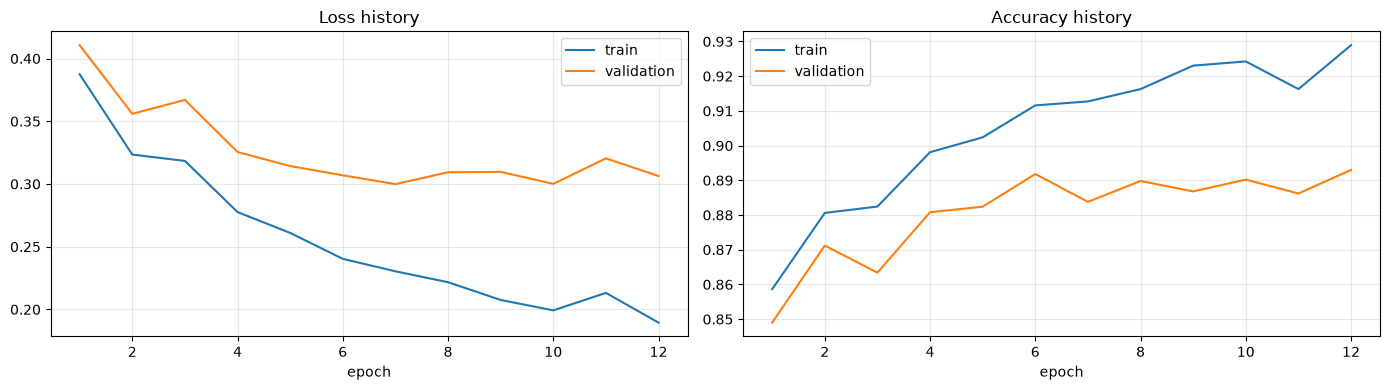

In [5]:
# ============================================================
# 【.py】MNISTMLP / fit_with_early_stopping を使う
# 元03では:
#   - class MNISTMLP をNotebook内定義
#   - for epoch in range(MAX_EPOCHS): ... Early Stopping を直書き
# ============================================================
set_seed(SEED)

# 【.py】models/mlp.py
model = MNISTMLP().to(device)

# 【.ipynb側】損失・optimizer・学習率は実験条件
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# 元03と同じく、モデル初期化後・学習開始直前にも seed を戻す
set_seed(SEED)

# 【.py】training/fit.py
# 中で train_one_epoch / evaluate を呼び、Early Stopping する
# 戻り値: model, best_epoch, best_validation_loss, history など
baseline_fit = fit_with_early_stopping(
    model=model,
    train_loader=train_loader,
    val_loader=validation_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    max_epochs=MAX_EPOCHS,   # 【.ipynb】実験条件
    patience=PATIENCE,       # 【.ipynb】実験条件
    min_delta=MIN_DELTA,
    train_eval_loader=train_eval_loader,  # corrected: shuffle 付き train_loader は再走査しない
    log_every_epoch=True,
)

model = baseline_fit["model"]
baseline_state = copy.deepcopy(model.state_dict())
# 監査対応: 同じrunのbaselineをRAMだけでなく保存する。再学習せず再検証できるようにする。
baseline_checkpoint_path = models_dir / "baseline_same_run.pt"
torch.save(baseline_state, baseline_checkpoint_path)


# 【.ipynb側】履歴を DataFrame / グラフにするのは実験ノートの仕事
df_training_history = pd.DataFrame(baseline_fit["history"])

print("Best epoch:", baseline_fit["best_epoch"])
print(f"Best validation loss: {baseline_fit['best_validation_loss']:.4f}")
display(df_training_history)

fig_learning, axes_learning = plt.subplots(1, 2, figsize=(14, 4))
axes_learning[0].plot(df_training_history["epoch"], df_training_history["train_loss"], label="train")
axes_learning[0].plot(df_training_history["epoch"], df_training_history["validation_loss"], label="validation")
axes_learning[0].set_title("Loss history")
axes_learning[0].set_xlabel("epoch")
axes_learning[0].legend()
axes_learning[0].grid(True, alpha=0.3)

axes_learning[1].plot(df_training_history["epoch"], df_training_history["train_acc"], label="train")
axes_learning[1].plot(df_training_history["epoch"], df_training_history["validation_acc"], label="validation")
axes_learning[1].set_title("Accuracy history")
axes_learning[1].set_xlabel("epoch")
axes_learning[1].legend()
axes_learning[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 5. SVD rank sweep

SVDでLinear層を置き換える処理は別のrankや別のNotebookでも使うため、`compression/svd.py` の `make_two_layer_svd_model` を呼びます。parameter数、MACs、agreement、logits RMSE、推論時間も `.py` 側の評価関数です。

一方、`R1_LIST`と`R2_LIST`、測定回数、どの指標をDataFrameに保存するかは今回の実験設計です。そのため、rankを総当たりするループと結果レコードの組み立てはNotebook側に置きます。

In [6]:
# ============================================================
# 【.ipynb側】rank候補の総当たりループと結果表の組み立て
# 【.py側】圧縮・評価・指標計算だけを関数として呼ぶ
# 元03では make_two_layer_svd_model / evaluate / MACs などもセル定義していた
# ============================================================
rank_configs = list(itertools.product(R1_LIST, R2_LIST))  # 【.ipynb】実験条件

# 【.py】metrics/model_comparison.py / metrics/mlp_macs.py
BENCH_WARMUP = 20
BENCH_REPEATS = 2000
# corrected: 原本は compressed 側の warmup/repeats が小さかった。同じ input_batch で揃える
inference_batch = take_inference_batch(validation_loader_rank)
baseline_bench = benchmark_inference(
    model,
    device=device,
    warmup=BENCH_WARMUP,
    repeats=BENCH_REPEATS,
    input_batch=inference_batch,
    return_details=True,
)
baseline_time_s = baseline_bench["time_s"]
print(
    "benchmark batch_size",
    baseline_bench["batch_size"],
    "shape",
    baseline_bench["input_shape"],
    "warmup",
    BENCH_WARMUP,
    "repeats",
    BENCH_REPEATS,
)
# 【.py】training/loops.py
baseline_rank_validation_loss, baseline_rank_validation_acc = evaluate(
    model,
    validation_loader_rank,
    criterion,
    device,
)

rank_results = []
for fc1_rank, fc2_rank in rank_configs:
    # 【.py】compression/svd.py（Linearを低ランク2層に置換）
    compressed_model = make_two_layer_svd_model(
        model,
        fc1_rank=fc1_rank,
        fc2_rank=fc2_rank,
    )
    validation_loss, validation_acc = evaluate(
        compressed_model,
        validation_loader_rank,
        criterion,
        device,
    )
    # 【.py】metrics/*
    drop = accuracy_drop(
        baseline_rank_validation_acc,
        validation_acc,
        verbose=False,
    )
    # 【.py】metrics/mlp_macs.py
    _, compressed_macs, compute_reduction = estimate_mlp_macs(
        model,
        fc1_rank,
        fc2_rank,
        verbose=False,
    )
    compressed_time_s = benchmark_inference(
        compressed_model,
        device=device,
        warmup=BENCH_WARMUP,
        repeats=BENCH_REPEATS,
        input_batch=inference_batch,
    )

    # 【.ipynb側】どの列を結果表に入れるかは実験設計
    row = {
        "fc1_rank": fc1_rank,
        "fc2_rank": fc2_rank,
        "parameters": count_parameters(compressed_model),
        "parameters_reduction": parameters_reduction(model, compressed_model),
        "validation_loss": validation_loss,
        "validation_acc": validation_acc,
        "accuracy_drop": drop,
        "compressed_macs": compressed_macs,
        "compute_reduction": compute_reduction,
        "baseline_time_ms": baseline_time_s * 1000,
        "compressed_time_ms": compressed_time_s * 1000,
        "agreement": agreement(model, compressed_model, validation_loader_rank, device),
        "logits_rmse": logits_rmse(model, compressed_model, validation_loader_rank, device),
        "retained_energy_fc1": retained_energy(model.fc1, fc1_rank),
        "retained_energy_fc2": retained_energy(model.fc2, fc2_rank),
        # benchmarkの対象batch・条件も保存し、後から別計測と区別する。
        "benchmark_batch_size": baseline_bench["batch_size"],
        "benchmark_input_shape": str(baseline_bench["input_shape"]),
        "benchmark_warmup": BENCH_WARMUP,
        "benchmark_repeats": BENCH_REPEATS,
    }
    rank_results.append(row)
    print(
        f"r1={fc1_rank:3d}, r2={fc2_rank:3d} | "
        f"Acc={validation_acc:.4f} loss={validation_loss:.4f} | "
        f"params={row['parameters']} MACs={compressed_macs} | "
        f"agreement={row['agreement']:.4f}"
    )

print(f"\n集計完了: {len(rank_results)} 件")


benchmark batch_size 64 shape (64, 1, 28, 28) warmup 20 repeats 2000


r1= 16, r2= 16 | Acc=0.7822 loss=0.6164 | params=36362 MACs=35584 | agreement=0.8290


r1= 16, r2= 32 | Acc=0.7818 loss=0.6188 | params=48650 MACs=47872 | agreement=0.8302


r1= 16, r2= 64 | Acc=0.7742 loss=0.6491 | params=73226 MACs=72448 | agreement=0.8226


r1= 16, r2=128 | Acc=0.7768 loss=0.6491 | params=122378 MACs=121600 | agreement=0.8252


...

r1=512, r2= 16 | Acc=0.8862 loss=0.3165 | params=679178 MACs=678400 | agreement=0.9806


r1=512, r2= 32 | Acc=0.8856 loss=0.3138 | params=691466 MACs=690688 | agreement=0.9878


r1=512, r2= 64 | Acc=0.8874 loss=0.3124 | params=716042 MACs=715264 | agreement=0.9942


r1=512, r2=128 | Acc=0.8876 loss=0.3102 | params=765194 MACs=764416 | agreement=0.9970


r1=512, r2=256 | Acc=0.8884 loss=0.3106 | params=863498 MACs=862720 | agreement=1.0000

集計完了: 30 件


## 6. Pareto frontierとknee候補

「他の点に支配されていない候補を抽出する」という判定ロジックは再利用可能なので、`selection/pareto.py` の `extract_pareto_frontier` を使います。直線から最も遠いknee点の計算も `selection/knee.py` からimportします。

一方、次はこの実験固有なのでNotebook側です。

- baselineよりparameter数が多い候補を除外する条件
- `parameters`と`validation_loss`を選ぶこと
- `MinMaxScaler`でどの列を正規化するか
- グラフの見せ方
- kneeの前後1点をfine-tuning候補にする判断

つまり、`.py`は「計算方法」、`.ipynb`は「今回その方法を何に適用するか」を担当します。

pareto points: 8


,fc1_rank,fc2_rank,parameters,validation_loss,parameters_normalize,validation_loss_normalize
0,16,16,36362,0.616395,0.000000,1.000000
1,32,16,57098,0.360735,0.139896,0.168512
2,32,32,69386,0.358668,0.222798,0.161790
3,32,64,93962,0.357239,0.388601,0.157145
4,64,16,98570,0.315666,0.419689,0.021934
5,64,32,110858,0.312992,0.502591,0.013238
6,64,64,135434,0.311357,0.668394,0.007920
7,64,128,184586,0.308921,1.000000,0.000000


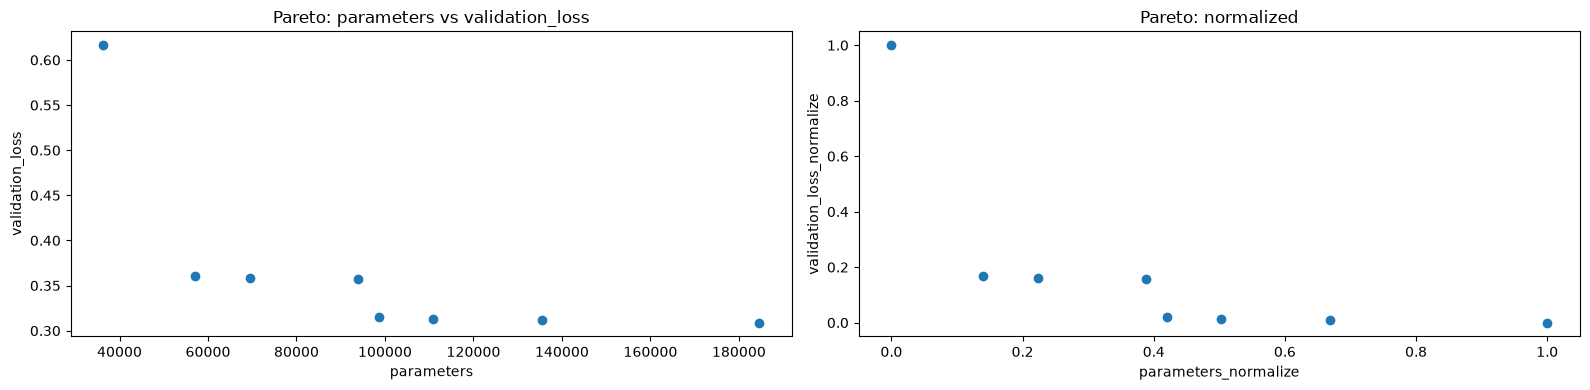

In [7]:
# ============================================================
# 【.ipynb側】前処理フィルタ・正規化・プロット
# 【.py側】Pareto frontier抽出だけ extract_pareto_frontier に任せる
# 元03では dominated判定の for ループをNotebook内に書いていた
# ============================================================
baseline_params = count_parameters(model)  # 【.py】metrics/model_comparison.py
df_rank_results = pd.DataFrame(rank_results)

# 【.ipynb側】「baselineより大きいparamsを落とす」等は実験判断
df_pareto_input = df_rank_results[
    (df_rank_results["parameters"] <= baseline_params)
    & (df_rank_results["compute_reduction"] > 0)
].copy()

# 【.py】selection/pareto.py
# 両目的とも小さいほど良い場合の非劣後点を返す
df_pareto_view = extract_pareto_frontier(
    df_pareto_input,
    x_column="parameters",
    y_column="validation_loss",
)

# 【.ipynb側】どの列を正規化するかは実験設計
scaler = MinMaxScaler()
df_pareto_view[
    ["parameters_normalize", "validation_loss_normalize"]
] = scaler.fit_transform(
    df_pareto_view[["parameters", "validation_loss"]]
)

# 【.ipynb側】可視化
fig_pareto, axes_pareto = plt.subplots(1, 2, figsize=(16, 4))
axes_pareto[0].scatter(
    df_pareto_view["parameters"],
    df_pareto_view["validation_loss"],
)
axes_pareto[0].set_xlabel("parameters")
axes_pareto[0].set_ylabel("validation_loss")
axes_pareto[0].set_title("Pareto: parameters vs validation_loss")

axes_pareto[1].scatter(
    df_pareto_view["parameters_normalize"],
    df_pareto_view["validation_loss_normalize"],
)
axes_pareto[1].set_xlabel("parameters_normalize")
axes_pareto[1].set_ylabel("validation_loss_normalize")
axes_pareto[1].set_title("Pareto: normalized")
plt.tight_layout()

print("pareto points:", len(df_pareto_view))
display(
    df_pareto_view[
        [
            "fc1_rank",
            "fc2_rank",
            "parameters",
            "validation_loss",
            "parameters_normalize",
            "validation_loss_normalize",
        ]
    ]
)
plt.show()

In [8]:
# ============================================================
# 【.py】get_first_point / line_equation / find_knee_point
# 元03の GetPoint / GetlinearEquation / GetKneePoint_loop を
# Python標準の snake_case 名へ整理して移植
# 【.ipynb側】knee±1を候補にする、という実験判断はここに残す
# ============================================================

# 【.py】selection/knee.py
# get_first_point: 指定列でソートした先頭点の座標を返す
p0 = get_first_point(
    df_pareto_view,
    "parameters_normalize",
    "parameters_normalize",
    "validation_loss_normalize",
)
p1 = get_first_point(
    df_pareto_view,
    "validation_loss_normalize",
    "parameters_normalize",
    "validation_loss_normalize",
)

# 端点を結ぶ直線から最も遠い点が knee
knee_point, knee_distance = find_knee_point(
    df_pareto_view,
    *line_equation(p0, p1),
    "parameters_normalize",
    "validation_loss_normalize",
)

# 【.ipynb側】kneeの前後1点もFine-tuning候補にする
df_pareto_view = df_pareto_view.sort_values("parameters").reset_index(drop=True)
knee_mask = (
    (df_pareto_view["parameters_normalize"] == knee_point[0])
    & (df_pareto_view["validation_loss_normalize"] == knee_point[1])
)
knee_pos = int(df_pareto_view.index[knee_mask][0])
left = max(knee_pos - 1, 0)
right = min(knee_pos + 1, len(df_pareto_view) - 1)

df_pareto_knee = df_pareto_view.iloc[[knee_pos]].copy()
df_pareto_best = df_pareto_view.iloc[left : right + 1].copy()

print("knee distance:", knee_distance)
print(f"knee_pos={knee_pos}, neighbors iloc[{left}:{right + 1}]")
print("knee:")
# corrected: rank 表に model 列は無い（include_model=False）
display(df_pareto_knee.drop(columns=["model"], errors="ignore"))
print("knee ±1:")
display(df_pareto_best.drop(columns=["model"], errors="ignore"))


knee distance: 0.48902888978562536
knee_pos=1, neighbors iloc[0:3]
knee:


,fc1_rank,fc2_rank,parameters,parameters_reduction,validation_loss,validation_acc,accuracy_drop,compressed_macs,compute_reduction,baseline_time_ms,...,agreement,logits_rmse,retained_energy_fc1,retained_energy_fc2,benchmark_batch_size,benchmark_input_shape,benchmark_warmup,benchmark_repeats,parameters_normalize,validation_loss_normalize
1,32,16,57098,0.893438,0.360735,0.8694,0.019,56320,0.894737,0.141979,...,0.9482,1.683634,0.743429,0.633641,64,"(64, 1, 28, 28)",20,2000,0.139896,0.168512


knee ±1:


,fc1_rank,fc2_rank,parameters,parameters_reduction,validation_loss,validation_acc,accuracy_drop,compressed_macs,compute_reduction,baseline_time_ms,...,agreement,logits_rmse,retained_energy_fc1,retained_energy_fc2,benchmark_batch_size,benchmark_input_shape,benchmark_warmup,benchmark_repeats,parameters_normalize,validation_loss_normalize
0,16,16,36362,0.932137,0.616395,0.7822,0.1062,35584,0.933493,0.141979,...,0.8290,3.967211,0.600048,0.633641,64,"(64, 1, 28, 28)",20,2000,0.000000,1.000000
1,32,16,57098,0.893438,0.360735,0.8694,0.0190,56320,0.894737,0.141979,...,0.9482,1.683634,0.743429,0.633641,64,"(64, 1, 28, 28)",20,2000,0.139896,0.168512
2,32,32,69386,0.870505,0.358668,0.8694,0.0190,68608,0.871770,0.141979,...,0.9468,1.490503,0.743429,0.737664,64,"(64, 1, 28, 28)",20,2000,0.222798,0.161790


## 7. knee ±1候補をFine-tuningする

Fine-tuningでも学習ループ自体は同じなので、再び `training/fit.py` の `fit_with_early_stopping` を使います。これが `.py` を切り出す大きな利点です。BaselineとFine-tuningでEarly Stoppingコードをコピーする必要がありません。

Notebook側には次を残します。

- knee前後のどのモデルを対象にするか
- 候補ごとにoptimizerを新しく作ること
- learning rate
- 候補ごとのseed規則
- 学習結果をどの列で記録するか

候補比較では **同じ SEED** と **同じ DataLoader Generator** に戻す。 rank ごとに seed をずらすと Dropout / shuffle が交絡する。


In [9]:
# ============================================================
# 【.ipynb側】どの候補をFine-tuningするか、候補ごとの seed / optimizer
# 【.py側】学習ループ本体は fit_with_early_stopping を再利用
# 元03では for re_epoch in range(MAX_EPOCHS): を直書きしていた
# ============================================================
set_seed(SEED)
fine_tuned_records = []

for _, pareto_row in df_pareto_best.iterrows():
    fc1_rank = int(pareto_row["fc1_rank"])
    fc2_rank = int(pareto_row["fc2_rank"])
    # corrected: include_model=False のため表から復元しない。baseline から rank で再構築する
    # corrected: 原本の SEED+1000*r1+r2 はやめ、全候補同じ SEED にする
    fine_tuned_model = make_two_layer_svd_model(
        model,
        fc1_rank=fc1_rank,
        fc2_rank=fc2_rank,
    ).to(device)

    candidate_optimizer = optim.Adam(
        fine_tuned_model.parameters(),
        lr=LEARNING_RATE,
    )
    set_seed(SEED)
    train_generator.manual_seed(SEED)
    print(f"\n=== fine-tune r1={fc1_rank}, r2={fc2_rank} ===")

    fit_result = fit_with_early_stopping(
        model=fine_tuned_model,
        train_loader=train_loader,
        val_loader=validation_loader,
        criterion=criterion,
        optimizer=candidate_optimizer,
        device=device,
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE,
        min_delta=MIN_DELTA,
        train_eval_loader=train_eval_loader,
        log_every_epoch=True,
    )

    fine_tuned_records.append(
        {
            "fc1_rank": fc1_rank,
            "fc2_rank": fc2_rank,
            "best_epoch": fit_result["best_epoch"],
            "best_validation_loss": fit_result["best_validation_loss"],
            "history": fit_result["history"],
            "model": fit_result["model"],
        }
    )

df_fine_tuned_models = pd.DataFrame(fine_tuned_records)
display(df_fine_tuned_models.drop(columns=["history", "model"]))



=== fine-tune r1=16, r2=16 ===


epoch=01 train_loss=0.3583 train_acc=0.8609 val_loss=0.4113 val_acc=0.8454


epoch=02 train_loss=0.3000 train_acc=0.8880 val_loss=0.3627 val_acc=0.8684


epoch=03 train_loss=0.3051 train_acc=0.8862 val_loss=0.3688 val_acc=0.8646


epoch=04 train_loss=0.2674 train_acc=0.8991 val_loss=0.3351 val_acc=0.8738


...

epoch=06 train_loss=0.2262 train_acc=0.9147 val_loss=0.3222 val_acc=0.8878


epoch=07 train_loss=0.2336 train_acc=0.9101 val_loss=0.3191 val_acc=0.8816


epoch=08 train_loss=0.2296 train_acc=0.9129 val_loss=0.3469 val_acc=0.8828


epoch=09 train_loss=0.1921 train_acc=0.9253 val_loss=0.3247 val_acc=0.8898
Early stopping at epoch 9


,fc1_rank,fc2_rank,best_epoch,best_validation_loss
0,16,16,5,0.320158
1,32,16,7,0.304973
2,32,32,4,0.313099


## 8. Fine-tuning前後の結果表とグラフ

`evaluate`の計算方法は共通なので `.py` 側です。しかし、候補を `Aggressive / Balanced / Conservative` と名付けること、どの列を比較するか、DataFrameやグラフをどう見せるかはこの実験だけの判断です。そのため `.ipynb` 側に置きます。

Fine-tuning後は、Early Stoppingに使った `validation_loader` ではなく、rank選択時と同じ `validation_loader_rank` で再評価します。これも元の03と同じ比較条件です。

,candidate,fc1_rank,fc2_rank,acc_before,acc_after,delta_acc,loss_before,loss_after,delta_loss
0,Aggressive,16,16,0.7822,0.8850,0.1028,0.616395,0.318649,-0.297745
1,Balanced,32,16,0.8694,0.8924,0.0230,0.360735,0.307956,-0.052778
2,Conservative,32,32,0.8694,0.8856,0.0162,0.358668,0.318636,-0.040031


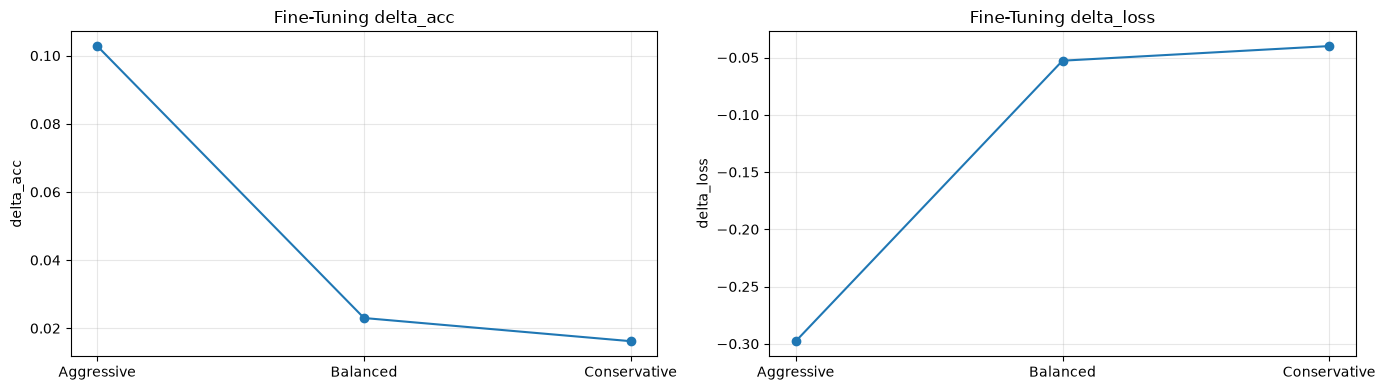

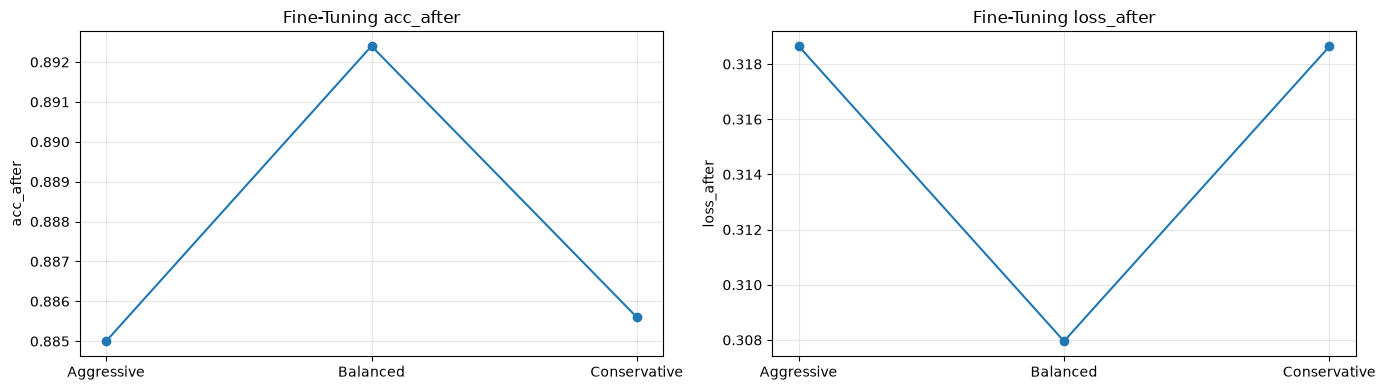

In [10]:
# ============================================================
# 【.ipynb側】候補名付け・比較表・グラフ（実験固有）
# 【.py側】evaluate だけ再利用
# ============================================================
fine_tuning_records = []

for idx, pareto_row in df_pareto_best.iterrows():
    fc1_rank = int(pareto_row["fc1_rank"])
    fc2_rank = int(pareto_row["fc2_rank"])

    # 【.ipynb側】kneeより左/本体/右のラベル（元03と同じ）
    if idx < knee_pos:
        candidate = "Aggressive"
    elif idx == knee_pos:
        candidate = "Balanced"
    else:
        candidate = "Conservative"

    matched = df_fine_tuned_models[
        (df_fine_tuned_models["fc1_rank"] == fc1_rank)
        & (df_fine_tuned_models["fc2_rank"] == fc2_rank)
    ]
    if len(matched) != 1:
        raise ValueError(
            f"Fine-tuning済みモデルが一意に見つかりません: "
            f"r1={fc1_rank}, r2={fc2_rank}, matches={len(matched)}"
        )

    # 【.py】evaluate。比較は Early Stopping用ではなく validation_loader_rank
    loss_after, acc_after = evaluate(
        matched.iloc[0]["model"],
        validation_loader_rank,
        criterion,
        device,
    )
    acc_before = float(pareto_row["validation_acc"])
    loss_before = float(pareto_row["validation_loss"])

    fine_tuning_records.append(
        {
            "candidate": candidate,
            "fc1_rank": fc1_rank,
            "fc2_rank": fc2_rank,
            "acc_before": acc_before,
            "acc_after": acc_after,
            "delta_acc": acc_after - acc_before,
            "loss_before": loss_before,
            "loss_after": loss_after,
            "delta_loss": loss_after - loss_before,
        }
    )

df_fine_tuning_result = pd.DataFrame(fine_tuning_records)
display(df_fine_tuning_result)

# 【.ipynb側】可視化
fig_delta, axes_delta = plt.subplots(1, 2, figsize=(14, 4))
axes_delta[0].plot(df_fine_tuning_result["candidate"], df_fine_tuning_result["delta_acc"], marker="o")
axes_delta[0].set_title("Fine-Tuning delta_acc")
axes_delta[0].set_ylabel("delta_acc")
axes_delta[0].grid(True, alpha=0.3)
axes_delta[1].plot(df_fine_tuning_result["candidate"], df_fine_tuning_result["delta_loss"], marker="o")
axes_delta[1].set_title("Fine-Tuning delta_loss")
axes_delta[1].set_ylabel("delta_loss")
axes_delta[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig_after, axes_after = plt.subplots(1, 2, figsize=(14, 4))
axes_after[0].plot(df_fine_tuning_result["candidate"], df_fine_tuning_result["acc_after"], marker="o")
axes_after[0].set_title("Fine-Tuning acc_after")
axes_after[0].set_ylabel("acc_after")
axes_after[0].grid(True, alpha=0.3)
axes_after[1].plot(df_fine_tuning_result["candidate"], df_fine_tuning_result["loss_after"], marker="o")
axes_after[1].set_title("Fine-Tuning loss_after")
axes_after[1].set_ylabel("loss_after")
axes_after[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. 最終モデルの選択とTest評価

Pareto抽出の計算は再び `.py` の `extract_pareto_frontier` を使います。一方、Fine-tuning後の候補から

1. validation lossが小さい
2. 同じならparameter数が少ない
3. さらに同じならvalidation accuracyが高い

という順で最終モデルを選ぶ方針は、今回の実験判断なのでNotebookに明記します。

Testデータはこの最終判断が終わってから一度だけ使います。これはTestへの過学習を避けるための実験設計です。

In [11]:
# ============================================================
# 【.ipynb側】比較表の組み立て・最終選択ルール
# 【.py側】extract_pareto_frontier / evaluate / count_parameters を再利用
# ============================================================
df_candidate_params = df_pareto_best[
    ["fc1_rank", "fc2_rank", "parameters", "parameters_reduction"]
].copy()
df_after_comparison = df_fine_tuning_result.merge(
    df_candidate_params,
    on=["fc1_rank", "fc2_rank"],
    how="left",
    validate="one_to_one",
)

comparison_records = [
    {
        "model": "Baseline",
        "fc1_rank": "-",
        "fc2_rank": "-",
        "validation_acc": baseline_rank_validation_acc,
        "validation_loss": baseline_rank_validation_loss,
        "parameters": baseline_params,
        "parameters_reduction": 0.0,
    }
]
for _, row in df_after_comparison.iterrows():
    comparison_records.append(
        {
            "model": f"{row['candidate']} after FT",
            "fc1_rank": int(row["fc1_rank"]),
            "fc2_rank": int(row["fc2_rank"]),
            "validation_acc": row["acc_after"],
            "validation_loss": row["loss_after"],
            "parameters": int(row["parameters"]),
            "parameters_reduction": row["parameters_reduction"],
        }
    )

df_model_comparison = pd.DataFrame(comparison_records)
display(df_model_comparison)

# Baselineは圧縮モデルの選択対象から除外
df_final_candidates = df_model_comparison[
    df_model_comparison["model"] != "Baseline"
].copy()

# 【.py】selection/pareto.py を再度利用
df_final_pareto = extract_pareto_frontier(
    df_final_candidates,
    x_column="parameters",
    y_column="validation_loss",
)

# 【.ipynb側】最終1モデルの優先順位（元03と同じ）
df_final_pareto = df_final_pareto.sort_values(
    by=["validation_loss", "parameters", "validation_acc"],
    ascending=[True, True, False],
).reset_index(drop=True)

final_model_result = df_final_pareto.iloc[0]
final_fc1_rank = int(final_model_result["fc1_rank"])
final_fc2_rank = int(final_model_result["fc2_rank"])
final_model = df_fine_tuned_models.loc[
    (df_fine_tuned_models["fc1_rank"] == final_fc1_rank)
    & (df_fine_tuned_models["fc2_rank"] == final_fc2_rank),
    "model",
].iloc[0]

print("Selected final model:")
display(df_final_pareto.iloc[[0]])
print(f"Final model: r1={final_fc1_rank}, r2={final_fc2_rank}")

# 最終選択後にTestを評価
final_test_loss, final_test_acc = evaluate(
    final_model,
    test_loader,
    criterion,
    device,
)
baseline_model_for_test = MNISTMLP().to(device)
baseline_model_for_test.load_state_dict(baseline_state)
baseline_test_loss, baseline_test_acc = evaluate(
    baseline_model_for_test,
    test_loader,
    criterion,
    device,
)

df_test_comparison = pd.DataFrame(
    [
        {
            "model": "Baseline",
            "fc1_rank": "-",
            "fc2_rank": "-",
            "parameters": baseline_params,
            "test_loss": baseline_test_loss,
            "test_acc": baseline_test_acc,
            "delta_test_acc": 0.0,
            "delta_test_loss": 0.0,
        },
        {
            "model": "Final (compressed + FT)",
            "fc1_rank": final_fc1_rank,
            "fc2_rank": final_fc2_rank,
            "parameters": count_parameters(final_model),
            "test_loss": final_test_loss,
            "test_acc": final_test_acc,
            "delta_test_acc": final_test_acc - baseline_test_acc,
            "delta_test_loss": final_test_loss - baseline_test_loss,
        },
    ]
)
display(df_test_comparison)

,model,fc1_rank,fc2_rank,validation_acc,validation_loss,parameters,parameters_reduction
0,Baseline,-,-,0.8884,0.310588,535818,0.000000
1,Aggressive after FT,16,16,0.8850,0.318649,36362,0.932137
2,Balanced after FT,32,16,0.8924,0.307956,57098,0.893438
3,Conservative after FT,32,32,0.8856,0.318636,69386,0.870505


Selected final model:


,model,fc1_rank,fc2_rank,validation_acc,validation_loss,parameters,parameters_reduction
0,Balanced after FT,32,16,0.8924,0.307956,57098,0.893438


Final model: r1=32, r2=16


,model,fc1_rank,fc2_rank,parameters,test_loss,test_acc,delta_test_acc,delta_test_loss
0,Baseline,-,-,535818,0.329024,0.8819,0.0000,0.000000
1,Final (compressed + FT),32,16,57098,0.333776,0.8853,0.0034,0.004752


## 10. 結果の保存

CSV名、PNG名、保存する列、モデル名はこの実験に固有なのでNotebook側です。`.py`側は「どう計算するか」を提供しますが、「今回の結果をどんな名前で残すか」は決めません。

このNotebookでは元の03を上書きしないよう、`results/10_svd/20_fashion_mnist_mlp/03_mlp_svd_finetuning_using_src/`と対応するmodelsディレクトリへ保存します。

In [12]:
# ============================================================
# 【.ipynb側】何をどのファイル名で残すか（実験固有）
# 【.py側】results_dir / models_dir は get_experiment_dirs が用意済み
# ============================================================
# 監査対応: 集計結果とepoch履歴を丸め前の値で保存する（新しい実行の成果物）。
# 過去の保存出力から復元した *_saved_output.csv / *_saved_log.csv は上書きしない。
df_rank_results.to_csv(results_dir / "rank_sweep_results.csv", index=False)
df_pareto_view.to_csv(results_dir / "pareto_frontier.csv", index=False)
df_pareto_best.to_csv(results_dir / "selected_rank_neighbors.csv", index=False)
df_training_history.to_csv(results_dir / "baseline_history.csv", index=False)
df_test_comparison.to_csv(results_dir / "test_comparison.csv", index=False)
df_fine_tuned_models.drop(columns=["model", "history"]).to_csv(
    results_dir / "fine_tuning_fit_summary.csv", index=False,
)
for _, fit_row in df_fine_tuned_models.iterrows():
    history_path = results_dir / (
        f"r1-{int(fit_row['fc1_rank'])}_r2-{int(fit_row['fc2_rank'])}_ft_history.csv"
    )
    pd.DataFrame(fit_row["history"]).to_csv(history_path, index=False)

# 元の03と同じFine-tuning関連成果物を保存
fine_tuning_csv = results_dir / "fine_tuning_result.csv"
model_comparison_csv = results_dir / "model_comparison.csv"
selected_final_csv = results_dir / "selected_final_model.csv"

df_fine_tuning_result.to_csv(fine_tuning_csv, index=False)
df_model_comparison.to_csv(model_comparison_csv, index=False)
pd.DataFrame([final_model_result]).to_csv(selected_final_csv, index=False)

pareto_figure_path = results_dir / "parameters_vs_validation_loss_normalize.png"
delta_figure_path = results_dir / "fine_tuning_delta.png"
after_figure_path = results_dir / "fine_tuning_after.png"
fig_pareto.savefig(pareto_figure_path, dpi=150, bbox_inches="tight")
fig_delta.savefig(delta_figure_path, dpi=150, bbox_inches="tight")
fig_after.savefig(after_figure_path, dpi=150, bbox_inches="tight")

saved_model_paths = []
for _, row in df_fine_tuned_models.iterrows():
    r1 = int(row["fc1_rank"])
    r2 = int(row["fc2_rank"])
    matched = df_fine_tuning_result[
        (df_fine_tuning_result["fc1_rank"] == r1)
        & (df_fine_tuning_result["fc2_rank"] == r2)
    ]
    tag = str(matched.iloc[0]["candidate"]).lower()
    model_path = models_dir / f"r1-{r1}_r2-{r2}_{tag}_finetuned.pt"
    torch.save(row["model"].state_dict(), model_path)
    saved_model_paths.append(model_path)

final_model_path = (
    models_dir / f"r1-{final_fc1_rank}_r2-{final_fc2_rank}_final.pt"
)
torch.save(final_model.state_dict(), final_model_path)

for path in [
    fine_tuning_csv,
    model_comparison_csv,
    selected_final_csv,
    pareto_figure_path,
    delta_figure_path,
    after_figure_path,
    *saved_model_paths,
    final_model_path,
]:
    print("saved:", path)


saved: D:\dev\nn-compression-svd-dmrg\results\10_svd\20_fashion_mnist_mlp\03_mlp_svd_finetuning_using_src_corrected_rerun_20260912T074153Z\fine_tuning_result.csv
saved: D:\dev\nn-compression-svd-dmrg\results\10_svd\20_fashion_mnist_mlp\03_mlp_svd_finetuning_using_src_corrected_rerun_20260912T074153Z\model_comparison.csv
saved: D:\dev\nn-compression-svd-dmrg\results\10_svd\20_fashion_mnist_mlp\03_mlp_svd_finetuning_using_src_corrected_rerun_20260912T074153Z\selected_final_model.csv
saved: D:\dev\nn-compression-svd-dmrg\results\10_svd\20_fashion_mnist_mlp\03_mlp_svd_finetuning_using_src_corrected_rerun_20260912T074153Z\parameters_vs_validation_loss_normalize.png
saved: D:\dev\nn-compression-svd-dmrg\results\10_svd\20_fashion_mnist_mlp\03_mlp_svd_finetuning_using_src_corrected_rerun_20260912T074153Z\fine_tuning_delta.png
saved: D:\dev\nn-compression-svd-dmrg\results\10_svd\20_fashion_mnist_mlp\03_mlp_svd_finetuning_using_src_corrected_rerun_20260912T074153Z\fine_tuning_after.png
saved: D:

## このNotebookでの役割分担

| `.py` に置くもの | `.ipynb` に置くもの |
|---|---|
| 再利用する処理 | 今回だけの実験条件 |
| `MNISTMLP`などのモデル定義 | rank候補 `R1_LIST`, `R2_LIST` |
| SVD分解・Linear層の置換 | learning rate、epoch数、patience |
| 1 epoch学習、評価、Early Stopping | optimizerの選択と作成 |
| seed固定、DataLoader作成 | split数、batch size |
| parameter数、agreement、RMSE、推論時間 | rank sweepの結果レコード・DataFrame |
| Pareto判定、knee距離計算 | 正規化する列、グラフ、CSV名 |
| 同じ入力に同じ計算を行う関数 | 最終rankの採用判断と実験考察 |

### 判断の目安

- 別のNotebookへコピーしたくなった処理は、`.py`に置く候補です。
- 値を変えて比較したい条件や、途中経過を見たい処理は、`.ipynb`に置く候補です。
- `.py`は「道具箱」、`.ipynb`は「その道具を使った実験ノート」と考えると整理しやすくなります。

### 元の03との実験ロジック確認

維持している条件：

- seedは0、決定論設定も同じ
- splitは50,000 / 5,000 / 5,000
- batch sizeはtrain/validationが64、testが1,000
- MLP構造、Adam、learning rate 0.001
- max epochs 50、patience 5、min delta `1e-4`
- rank候補、rank sweep指標、Pareto条件、正規化、knee ±1
- 候補別seed、Fine-tuning、最終選択順、最後のTest評価

意図的な差は次の2点だけです。

1. 重複関数をNotebook内で定義せず、`nn_compression`からimportする
2. 元の実験結果を上書きしないよう、出力先のexperiment名に `_using_src` を付ける

セル内の表示方法や変数名は教材として読みやすく整理していますが、学習・圧縮・選択の数値ロジックは変更していません。

## 新規runの完全保存

以下は実験記録の保存用。過去runの欠落値を推定せず、このkernelで得た未丸め値・epoch履歴・checkpointを保存する。


In [13]:
# 新しいrunの成果物を不足なく残す。既存のhistorical出力先は使用しない。
import copy
import hashlib
import json
import platform
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import torch
from nn_compression.metrics import benchmark_inference, take_inference_batch, count_parameters

def _run_sha256(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

_baseline_fit = globals().get("baseline_fit", globals().get("fit"))
assert _baseline_fit is not None
# baseline_stateは圧縮前のsnapshot。FT後checkpointから元重みを推定しない。
_baseline_model = copy.deepcopy(_baseline_fit["model"])
if "baseline_state" in globals():
    _baseline_model.load_state_dict(baseline_state)
torch.save(_baseline_model.state_dict(), models_dir / "baseline_same_run.pt")
pd.DataFrame(_baseline_fit["history"]).to_csv(results_dir / "baseline_history.csv", index=False)
_run_fit_summary = [{
    "stage": "baseline", "best_epoch": _baseline_fit["best_epoch"],
    "best_validation_loss": _baseline_fit["best_validation_loss"],
    "epochs_ran": len(_baseline_fit["history"]),
}]
_run_ft_records = []
if "df_fine_tuned_models" in globals():
    for _, _fit_row in df_fine_tuned_models.iterrows():
        _rank_fields = {c: int(_fit_row[c]) for c in ("fc1_rank", "fc2_rank", "conv2_rank") if c in _fit_row}
        _history_frame = pd.DataFrame(_fit_row["history"]).copy()
        _history_name = "_".join(f"{k}-{v}" for k, v in _rank_fields.items()) + "_ft_history.csv"
        _history_frame.to_csv(results_dir / _history_name, index=False)
        _run_fit_summary.append({
            "stage": "fine_tuning", **_rank_fields,
            "best_epoch": int(_fit_row["best_epoch"]),
            "best_validation_loss": float(_fit_row["best_validation_loss"]),
            "epochs_ran": len(_history_frame),
        })
        for _history_row in _history_frame.to_dict("records"):
            _run_ft_records.append({**_rank_fields, **_history_row})
elif "fine_tune_result" in globals():
    _history_frame = pd.DataFrame(fine_tune_result["history"])
    _history_frame.to_csv(results_dir / "fine_tuning_history.csv", index=False)
    _run_fit_summary.append({
        "stage": "fine_tuning", "conv2_rank": CONV2_RANK, "fc1_rank": FC1_RANK,
        "best_epoch": int(fine_tune_result["best_epoch"]),
        "best_validation_loss": float(fine_tune_result["best_validation_loss"]),
        "epochs_ran": len(_history_frame),
    })
    _run_ft_records = [{ "conv2_rank": CONV2_RANK, "fc1_rank": FC1_RANK, **r } for r in _history_frame.to_dict("records")]
if _run_ft_records:
    pd.DataFrame(_run_ft_records).to_csv(results_dir / "all_fine_tuning_history.csv", index=False)
pd.DataFrame(_run_fit_summary).to_csv(results_dir / "fit_summary.csv", index=False)

_rank_loader = globals().get("validation_loader_rank", globals().get("val_rank_loader"))
assert _rank_loader is not None
_run_inputs = take_inference_batch(_rank_loader)
_run_input_sha256 = hashlib.sha256(_run_inputs.numpy().tobytes()).hexdigest()
_run_warmup = globals().get("BENCH_WARMUP", 20)
_run_repeats = globals().get("BENCH_REPEATS", 2000)
for _name, _filename in (
    ("df_rank_results", "rank_sweep_results.csv"),
    ("df_pareto_view", "pareto_frontier.csv"),
    ("df_pareto_best", "selected_rank_neighbors.csv"),
):
    if _name in globals():
        _frame = globals()[_name].drop(columns=["model", "history"], errors="ignore").copy()
        if _name == "df_rank_results":
            _frame["benchmark_batch_size"] = len(_run_inputs)
            _frame["benchmark_input_shape"] = str(tuple(_run_inputs.shape))
            _frame["benchmark_input_sha256"] = _run_input_sha256
            _frame["benchmark_warmup"] = _run_warmup
            _frame["benchmark_repeats"] = _run_repeats
            _frame["benchmark_stage"] = "rank_sweep_before_finetuning"
        _frame.to_csv(results_dir / _filename, index=False)
_run_test = globals().get("df_test_comparison", globals().get("summary"))
assert _run_test is not None
_run_test.to_csv(results_dir / "test_comparison.csv", index=False)
torch.save(final_model.state_dict(), models_dir / "final_same_run.pt")
_run_benchmarks = []
for _trial in range(1, 4):
    _pairs = [("baseline", _baseline_model), ("final", final_model)]
    if _trial % 2 == 0:
        _pairs.reverse()
    for _label, _benchmark_model in _pairs:
        _details = benchmark_inference(
            _benchmark_model, device=device, input_batch=_run_inputs,
            warmup=_run_warmup, repeats=_run_repeats, return_details=True,
        )
        _run_benchmarks.append({
            "trial": _trial, "model": _label, "time_ms": _details["time_ms"],
            "parameters": count_parameters(_benchmark_model),
            "batch_size": _details["batch_size"], "input_shape": str(_details["input_shape"]),
            "warmup": _run_warmup, "repeats": _run_repeats,
            "stage": "final_after_finetuning" if _run_ft_records else "final_compression_only",
            "input_sha256": _run_input_sha256,
        })
_run_benchmark_frame = pd.DataFrame(_run_benchmarks)
_run_benchmark_frame.to_csv(results_dir / "final_model_benchmark.csv", index=False)
_run_csv_hashes = [
    {"path": p.relative_to(_run_root).as_posix(), "sha256": _run_sha256(p), "bytes": p.stat().st_size}
    for p in sorted(results_dir.iterdir()) if p.suffix in (".csv", ".png")
]
_run_checkpoints = [
    {"path": p.relative_to(_run_root).as_posix(), "sha256": _run_sha256(p), "bytes": p.stat().st_size}
    for p in sorted(models_dir.glob("*.pt"))
]
_run_notebook = _run_root / RUN_NOTEBOOK_RELATIVE
_run_code = json.loads(_run_notebook.read_text(encoding="utf-8"))["cells"]
_run_manifest = {
    "run_id": RUN_BATCH_ID, "experiment": EXPERIMENT_NAME,
    "source_notebook": RUN_SOURCE_RELATIVE, "executed_notebook": RUN_NOTEBOOK_RELATIVE,
    "status": "completed fresh run; NOT reconstruction of historical missing artifacts",
    "completed_at_utc": datetime.now(timezone.utc).isoformat(),
    "code_source_sha256": hashlib.sha256(json.dumps(
        ["".join(c["source"]) for c in _run_code if c["cell_type"] == "code"],
        ensure_ascii=False, separators=(",", ":"),
    ).encode("utf-8")).hexdigest(),
    "source_snapshot_sha256": RUN_SOURCE_SNAPSHOT_SHA256,
    "csv_precision": "direct pandas export of in-memory values; no display rounding",
    "seed": SEED,
    "split_lengths": [len(train_loader.dataset), len(_rank_loader.dataset)],
    "fit_summary": _run_fit_summary,
    "test_records": _run_test.to_dict("records"),
    "benchmark": {
        "warmup": _run_warmup, "repeats": _run_repeats, "trials": 3,
        "input_sha256": _run_input_sha256, "input_shape": list(_run_inputs.shape),
        "definition": "mean forward ms/batch per trial; eval/no_grad; H2D excluded; CUDA synchronized",
        "median_ms": _run_benchmark_frame.groupby("model")["time_ms"].median().to_dict(),
    },
    "environment": {
        "python": platform.python_version(), "torch": str(torch.__version__),
        "cuda": torch.version.cuda, "gpu": torch.cuda.get_device_name(device),
        "cudnn": torch.backends.cudnn.version(),
        "cudnn_benchmark": torch.backends.cudnn.benchmark,
        "cudnn_deterministic": torch.backends.cudnn.deterministic,
        "matmul_tf32": torch.backends.cuda.matmul.allow_tf32,
        "cudnn_tf32": torch.backends.cudnn.allow_tf32,
        "cpu_threads": torch.get_num_threads(),
    },
    "artifacts": _run_csv_hashes, "checkpoints": _run_checkpoints,
}
with (results_dir / "run_manifest.json").open("w", encoding="utf-8") as _f:
    json.dump(_run_manifest, _f, ensure_ascii=False, indent=2)
print("新規run完了:", EXPERIMENT_NAME)
print("成果物:", results_dir)
print("checkpoint:", models_dir)
print(_run_test.to_string(index=False))


新規run完了: 03_mlp_svd_finetuning_using_src_corrected_rerun_20260912T074153Z
成果物: D:\dev\nn-compression-svd-dmrg\results\10_svd\20_fashion_mnist_mlp\03_mlp_svd_finetuning_using_src_corrected_rerun_20260912T074153Z
checkpoint: D:\dev\nn-compression-svd-dmrg\models\10_svd\20_fashion_mnist_mlp\03_mlp_svd_finetuning_using_src_corrected_rerun_20260912T074153Z
                  model fc1_rank fc2_rank  parameters  test_loss  test_acc  delta_test_acc  delta_test_loss
               Baseline        -        -      535818   0.329024    0.8819          0.0000         0.000000
Final (compressed + FT)       32       16       57098   0.333776    0.8853          0.0034         0.004752
